In [4]:
import pandas as pd
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score)


In [5]:
# ___________________________LOAD DATA ________________________________

df = pd.read_csv("model_dataset.csv")



y = df["readmitted_30d"]    # target variable


remove_columns = [       #remove identifiers
    "readmitted_30d",
    "subject_id",
    "hadm_id",
    "next_admission"
]

remove_columns = [
    c for c in remove_columns
    if c in df.columns
]

X = df.drop(columns=remove_columns)

In [6]:

# ____________________________TRAIN TEST SPLIT __________________________________

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )
)

In [7]:

# ________________________________COLUMN TYPES _______________________________

numeric_columns = (
    X.select_dtypes(include="number")
    .columns)

categorical_columns = (
    X.select_dtypes(exclude="number")
    .columns)


In [8]:
# _____________________________PREPROCESSOR __________________________________


preprocessor = ColumnTransformer(
    [
        (
            "num",
            Pipeline(
                [
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="median"
                        )
                    )
                ]
            ),
            numeric_columns
        ),
        (
            "cat",
            Pipeline(
                [
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="most_frequent"
                        )
                    ),
                    (
                        "encoder",
                        OneHotEncoder(
                            handle_unknown="ignore"
                        )
                    )
                ]
            ),
            categorical_columns
        )
    ]
)


In [9]:
# ________________________________RANDOM FOREST MODEL ______________________________________

model = Pipeline(
    [
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=400,
                max_depth=16,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


In [10]:
# __________________________TRAIN ____________________________

model.fit(
    X_train,
    y_train
)


# __________________________________PREDICT ____________________________________


predictions = model.predict(
    X_test
)

probabilities = (
    model.predict_proba(X_test)[:, 1]
)


In [11]:
# __________________________CALCULATE METRICS ________________________________


metrics = pd.DataFrame(
    [
        {
            "accuracy":
                accuracy_score(
                    y_test,
                    predictions
                ),

            "precision":
                precision_score(
                    y_test,
                    predictions
                ),

            "recall":
                recall_score(
                    y_test,
                    predictions
                ),

            "f1":
                f1_score(
                    y_test,
                    predictions
                ),

            "roc_auc":
                roc_auc_score(
                    y_test,
                    probabilities
                )
        }
    ]
)

metrics.to_csv(
    "model2_metrics.csv",
    index=False)

In [12]:
# _________________________________SAVE PREDICTIONS _____________________________

prediction_df = pd.DataFrame(
    {
        "actual": y_test,
        "prediction": predictions,
        "probability": probabilities
    })

prediction_df.to_csv(
    "model2_predictions.csv",
    index=False)

print(metrics)


   accuracy  precision    recall       f1   roc_auc
0  0.868313   0.624984  0.880389  0.73102  0.946255


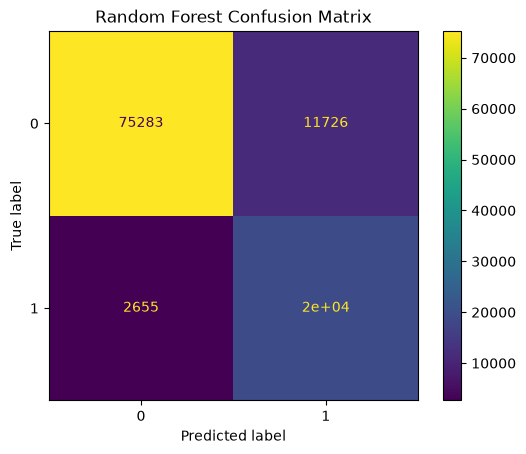

In [13]:
ConfusionMatrixDisplay.from_predictions(
y_test,
predictions)

plt.title("Random Forest Confusion Matrix")
plt.savefig("confusion_matrix_model2.png")
plt.show()